In [1]:
import os

# --- JAX / CUDA GPU MEMORY MANAGEMENT CONFIGURATION ---
# MUST be set at the very top of the notebook BEFORE 'import jax' or 'import flax'!
# 1. Disable JAX's default 75% GPU memory pre-allocation.
#    By default, JAX claims 75% of total GPU VRAM upfront upon initialization.
#    Setting this to "false" forces JAX to allocate GPU memory dynamically as needed,
#    preventing Out-Of-Memory (OOM) errors when sharing GPUs or running large intermediate graphs.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"
# 2. Use the CUDA Async Memory Allocator for XLA.
#    Replaces XLA's default rigid BFC (Best-Fit with Coalscing) allocator with CUDA's native 
#    async pool allocator. This reduces memory fragmentation during large intermediate tensor 
#    transformations (e.g. high-resolution L=1500 spherical convolutions/FFTs).
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

print("--- Environment Variables inside Container ---")
print("CUDA_VISIBLE_DEVICES  :", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("NVIDIA_VISIBLE_DEVICES:", os.environ.get("NVIDIA_VISIBLE_DEVICES"))

print("\n--- Testing nvidia-smi ---")
os.system("nvidia-smi")

import socket

print("=== VS CODE CONTAINER DIAGNOSTIC ===")
print("1. Hostname               :", socket.gethostname())
print("2. Slurm Job ID           :", os.environ.get("SLURM_JOB_ID", "NONE (Running outside Slurm!)"))
print("3. CUDA_VISIBLE_DEVICES   :", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("4. Apptainer GPU Devices  :", [f for f in os.listdir('/dev') if 'nvidia' in f] if os.path.exists('/dev') else "No /dev")

import sys

print("1. Python Binary  :", sys.executable)
print("2. Site-Packages  :", [p for p in sys.path if ".venv" in p])
print("3. CUDA Available :")

import torch
print("torch", torch.__version__, torch.cuda.is_available(), f"({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else "")

import jax
jax.config.update("jax_enable_x64", True)
print("Jax version", jax.__version__, "64-bit", jax.config.read("jax_enable_x64"))
print("jax", jax.__version__, "GPU backend:", jax.default_backend() == 'gpu', f"({jax.devices('gpu')[0].device_kind})" if jax.default_backend() == 'gpu' else "")

: 

In [ ]:
import os
# 1. Force JAX to see the GPU
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# 2. Keep CPU threads from crashing if it falls back
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"
# 3. Provide valid temporary directory for ptxas CUDA kernel compilation
os.environ["TMPDIR"] = "/tmp"
os.environ["TMP"] = "/tmp"
os.environ["TEMP"] = "/tmp"

import dataclasses
import numpy as np

import jax.numpy as jnp
import flax
print("Flax version", flax.__version__)
from flax import nnx
import optax
# from sbi_compression.methods.utils import universal_flax_nnx_shim
# universal_flax_nnx_shim()

from torch.utils.data import Dataset, DataLoader, random_split

from s2ai.blocks.core_blocks import DiscoConvBlock, AverageBlock
from typing import Any, List, Optional, Callable, Sequence, Tuple, Union
from jaxtyping import Array, Float, Int, PyTree # https://github.com/google/jaxtyping

from typing import Literal, Callable, Optional
from tqdm import tqdm
from math import prod


class DiscoCNN(nnx.Module):
    """Disco convolutional network with spherical group normalisation."""

    def __init__(
        self,
        modes: List[str] = dataclasses.field(
            default_factory=lambda: ["disco", "disco", "disco", "disco"]
        ),
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        # These could be nnx.vmapped/scanned for faster initialization
        self.disco_conv_block_0 = DiscoConvBlock(
            (128, 64), (1, 4), 2, mode=modes[0], rngs=rngs
        )
        self.disco_conv_block_1 = DiscoConvBlock(
            (64, 32), (4, 16), 4, mode=modes[1], rngs=rngs
        )
        self.disco_conv_block_2 = DiscoConvBlock(
            (32, 16), (16, 64), 8, mode=modes[2], rngs=rngs
        )
        self.disco_conv_block_3 = DiscoConvBlock(
            (16, 8), (64, 256), 16, mode=modes[3], rngs=rngs
        )

        self.average_block = AverageBlock(L_in=8)

        self.dropout_4 = nnx.Dropout(0.5, rngs=rngs)
        self.dense_4 = nnx.Linear(
            in_features=256,
            out_features=256,
            rngs=rngs,
        )
        self.activation_4 = nnx.swish

        self.dropout_5 = nnx.Dropout(0.5, rngs=rngs)
        self.dense_5 = nnx.Linear(
            in_features=256,
            out_features=10,
            rngs=rngs,
        )
        self.activation_5 = nnx.log_softmax

    def __call__(self, x):
        # Spherical convolutional blocks (L's, channels, groups)
        x = self.disco_conv_block_0(x)
        x = self.disco_conv_block_1(x)
        x = self.disco_conv_block_2(x)
        x = self.disco_conv_block_3(x)

        # Convert to equivariant dense layer
        x = self.average_block(x)

        # Standard MLP classifier
        x = self.dropout_4(x)
        x = self.dense_4(x)
        x = self.activation_4(x)
        x = self.dropout_5(x)
        x = self.dense_5(x)
        x = self.activation_5(x)
        return x



Flax version 0.12.7


In [3]:
class DiscoCNNBuild(nnx.Module):
    "Builds spherical convolutional network based on set of tuples defining the convolution block per layer."
    def __init__(
        self,
        input_shape: tuple[int, ...],
        output_dim: int,
        layer_dims: list,
        activation: Callable = nnx.leaky_relu,
        rngs: nnx.Rngs | None = None, 
        ):

        if rngs is None:
            rngs = nnx.Rngs(0)

        self.input_shape = tuple(input_shape)
        self.output_dim = output_dim
        self.layer_dims = tuple(tuple(x) if not isinstance(x, tuple) else x for x in layer_dims)
        if len(self.layer_dims) == 0:
            raise ValueError("At least one layer dimension must be specified in layer_dims.")
        self.activation = activation
        self.rngs = rngs
        self.layers = nnx.List()
        
        raise NotImplementedError

    def check_layer_dims(
        self,
        input_shape: tuple[int, ...],
        output_dim: int,
        layer_dims: list,
        ):
        
        raise NotImplementedError

    def _add_layer(
        self,
        layer_dim: tuple,
        prev_layer_dim: tuple | None,
        layers: nnx.List,
        ):

        if prev_layer_dim is None:
            if len(layer_dim) == 2:
                if len(self.input_shape) == 1:
                    if self.input_shape[0] != layer_dim[0]:
                        raise ValueError(
                            f"Expected input shape {self.input_shape} to match linear "
                            f"input dimension {layer_dim[0]}."
                        )
                    layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))
                elif len(self.input_shape) == 3:
                    if prod(self.input_shape) != layer_dim[0]:
                        raise ValueError(
                            f"Expected flattened input size {prod(self.input_shape)} to "
                            f"match linear input dimension {layer_dim[0]}."
                        )
                    layers.append(self.Flatten())
                    layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))
                else:
                    raise ValueError(f"Unsupported input shape {self.input_shape}.")

            elif len(layer_dim) == 3:
                if len(self.input_shape) != 3:
                    raise ValueError(
                        f"Cannot add a convolutional layer after a linear layer, got "
                        f"layer dimensions {layer_dim} after input shape {self.input_shape}."
                    )
                if self.input_shape[2] != layer_dim[0]:
                    raise ValueError(
                        f"Expected input channels {self.input_shape[2]} to match "
                        f"convolutional input channels {layer_dim[0]}."
                    )
                layers.append(
                    nnx.Conv(
                        layer_dim[0],
                        layer_dim[1],
                        kernel_size=(layer_dim[2], layer_dim[2]),
                        padding="VALID",
                        rngs=self.rngs,
                    )
                )   

        else:
            if len(layer_dim) == 2 and len(prev_layer_dim) == 2:
                if prev_layer_dim[1] != layer_dim[0]:
                    raise ValueError(
                        f"Linear layer input dimension {layer_dim[0]} does not match "
                        f"previous layer output dimension {prev_layer_dim[1]}."
                    )
                layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))

            elif len(layer_dim) == 3 and len(prev_layer_dim) == 3:
                if prev_layer_dim[1] != layer_dim[0]:
                    raise ValueError(
                        f"Convolutional layer input channels {layer_dim[0]} do not match "
                        f"previous layer output channels {prev_layer_dim[1]}."
                    )
                layers.append(
                    nnx.Conv(
                        layer_dim[0],
                        layer_dim[1],
                        kernel_size=(layer_dim[2], layer_dim[2]),
                        padding="VALID",
                        rngs=self.rngs,
                    )
                )

            elif len(layer_dim) == 2 and len(prev_layer_dim) == 3:
                layers.append(self.Flatten())
                layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))

            elif len(layer_dim) == 3 and len(prev_layer_dim) == 2:
                raise ValueError(
                    f"Cannot add a convolutional layer after a linear layer, got "
                    f"layer dimensions {layer_dim} after {prev_layer_dim}."
                )

        raise NotImplementedError
    
    def __call__(self, x):
        if len(self.layers) > 1:
            for layer in self.layers[:-1]:
                x = layer(x)
                x = self.activation(x)
            x = self.layers[-1](x)
        elif len(self.layers) == 1:
            for layer in self.layers:
                x = layer(x)
        return x


In [4]:
# directory = "/Users/brian/Downloads/map_compression_samples_5_tomo_bins_flm_1500_batch_1"
# directory = "/scratch/u6pf/brianycc.u6pf/spherical_maps/map_compression_samples_5_tomo_bins_flm_1500_batch_1/"
directory = "/projects/u6pf/brianycc/spherical_maps/5_tomo_bins_flm_750_batch_1_mwss/"
# n_map = 1
t = np.load(directory+f'/map_{1}.npy')
print(t.shape)
p = np.load(directory+"/params.npy")
print(p.shape)

# m = []
# for i in range(n_map):
#     m_add = np.load(directory+f'/map_{i}.npy')
#     m.append(m_add)
#     if i % 50 == 0 :
#         print(m_add.shape)
#         print(len(m))
# m = np.asarray(m)
# m = m.reshape((-1, 1500, 2*1500-1, 5)) 

(751, 1500, 5)
(2000, 5)


In [ ]:
import s2fft

class SphericalMapDataset(Dataset):
    def __init__(self, 
        directory, 
        n_maps = 1000, 
        param_filename = "params.npy",
        normalise_params = True,
        normalise_maps = True,):
        """
        Args:
            directory (str): Path to the folder containing map_{i}.npy.
            n_maps (int): Total number of map samples to load.
            param_filename (str): Name of the parameters numpy file.
        """
        self.directory = directory
        self.n_maps = n_maps
        self.normalize_maps = normalize_maps
        self.normalize_params = normalize_params

        # The parameters file is tiny, so it is safe to load entirely into RAM
        param_path = os.path.join(directory, param_filename)
        raw_params = np.load(param_path)
        assert self.n_maps <= len(raw_params), f"Requested {self.n_maps} maps, but params.npy only has {len(raw_params)} rows!"
        
        # --- 1. Parameter Standardization ---
        self.normalize_params = normalize_params
        if self.normalize_params:
            self.param_mean = np.mean(raw_params, axis=0, keepdims=True)
            self.param_std = np.std(raw_params, axis=0, keepdims=True) #+ 1e-8
            self.params = (raw_params - self.param_mean) / self.param_std
        else:
            self.params = raw_params
            # self.param_mean = np.zeros((1, raw_params.shape[1]))
            # self.param_std = np.ones((1, raw_params.shape[1]))

        # 2. Load Pre-computed Map Stats
        if self.normalize_maps:
            stats_path = os.path.join(directory, stats_filename)
            assert os.path.exists(stats_path), f"Stats file {stats_path} not found! Run compute_and_save_map_stats first."
            
            stats = np.load(stats_path)
            # Shape for broadcasting over (theta, phi, channels): (1, 1, channels)
            self.map_mean = stats["mean"].reshape(1, 1, -1)
            self.map_std = stats["std"].reshape(1, 1, -1) #+ 1e-8

    def __len__(self):
        return self.n_maps
    
    def __getitem__(self, idx):
        # Lazily load only ONE map to memory on demand
        map_path = os.path.join(self.directory, f"map_{idx}.npy")
        m = np.load(map_path)
        p = self.params[idx].astype(np.float32)
        # Standardize Map dynamically per channel
        if self.normalize_maps:
            m = (m - self.map_mean) / self.map_std
        return m, p


In [50]:
class In1500_Out5_DiscoCNN(nnx.Module):
    """Disco convolutional network with spherical group normalisation."""

    def __init__(
        self,
        # modes: List[str] = dataclasses.field(
        #     default_factory=lambda: ["disco", "disco", "disco", "disco"]
        # ),
        modes: tuple[str] = ("disco", "disco", "disco", "disco"),
        rngs: nnx.Rngs = nnx.Rngs(0),
        verbose: bool = False,
    ):
        self.verbose = verbose

        # These could be nnx.vmapped/scanned for faster initialization
        # self.disco_conv_block_0 = DiscoConvBlock(
        #     (1500, 750), (5, 5), 5, mode=modes[0], rngs=rngs
        # )
        self.disco_conv_block_1 = DiscoConvBlock(
            (750, 250), (5, 10), 10, mode=modes[1], rngs=rngs
        )
        self.disco_conv_block_2 = DiscoConvBlock(
            (250, 50), (10, 20), 20, mode=modes[2], rngs=rngs
        )
        self.disco_conv_block_3 = DiscoConvBlock(
            (50, 10), (20, 40), 40, mode=modes[3], rngs=rngs
        )

        self.average_block = AverageBlock(L_in=10)

        self.dropout_4 = nnx.Dropout(0.5, rngs=rngs)
        self.dense_4 = nnx.Linear(
            in_features=40,
            out_features=20,
            rngs=rngs,
        )
        self.activation_4 = nnx.swish

        self.dropout_5 = nnx.Dropout(0.5, rngs=rngs)
        self.dense_5 = nnx.Linear(
            in_features=20,
            out_features=5,
            rngs=rngs,
        )
        self.activation_5 = nnx.log_softmax

    @nnx.remat
    def __call__(self, x):
        # Spherical convolutional blocks (L's, channels, groups)
        # x = self.disco_conv_block_0(x)
        x = self.disco_conv_block_1(x)
        x = self.disco_conv_block_2(x)
        x = self.disco_conv_block_3(x)
        jax.debug.print("Past disco block.") if self.verbose else None
        # Convert to equivariant dense layer
        x = self.average_block(x)
        # Standard MLP classifier
        x = self.dropout_4(x)
        x = self.dense_4(x)
        x = self.activation_4(x)
        x = self.dropout_5(x)
        x = self.dense_5(x)
        # x = self.activation_5(x)
        jax.debug.print("Past dense mlp.") if self.verbose else None
        return x

s2_CNN = In1500_Out5_DiscoCNN()

from sbi_compression.methods.neural.flows import RQSplineFlow
import distrax

features_shape = (5,)
context_shape = (5,)
features_dim = prod(features_shape)
context_dim = prod(context_shape)
n_transforms = 4
n_bins = 12
range_min = -6
range_max = 6
bijector_type = distrax.RationalQuadraticSpline
conditioner_hidden_dims = ((64,64), (64,64))
activation = "gelu"
flow = RQSplineFlow(
    features_dim, 
    context_dim, 
    n_transforms=n_transforms, 
    hidden_dims=conditioner_hidden_dims, 
    activation=getattr(nnx, activation), 
    n_bins=n_bins, 
    range_min=range_min, 
    range_max=range_max, 
    bijector_type=bijector_type
    )

class s2_AE_Flow(nnx.Module):

    def __init__(self,
        encoder: nnx.Module,
        flow: nnx.Module,
        encoder_mode: Literal['context', 'features'],
        verbose: bool = False,
        ):
        self.encoder_mode = encoder_mode
        self.encoder = encoder
        self.flow = flow
        self.verbose = verbose
    
    def __call__(self, x: Array, context: Array) -> Array:
        if self.encoder_mode == 'context':
            context_encoded = self.encoder(context)
            x = self.flow(x, context_encoded)
        elif self.encoder_mode == 'features':
            x_encoded = self.encoder(x)
            x = self.flow(x_encoded, context)
        jax.debug.print("Past flow.") if self.verbose else None
        return x
    
    def sample(self, num_samples: int, rng: Array, context: Array) -> Array:
        x = self.flow.sample(num_samples, rng, context)
        return x
        
    def encode(self, x: Array) -> Array:
        # assert x.shape[-len(self.input_shape):] == self.input_shape # Make sure the input shape matches the encoder, assume batch first
        x = self.encoder(x)
        return x
    
    def mode(self, mode: Literal['train_encoder', 'train_flow', 'train_all', 'eval']) -> None:
        if mode == 'train_encoder':
            self.encoder.train()
            self.flow.eval()
        elif mode == 'train_flow':
            self.encoder.eval()
            self.flow.train()
        elif mode == 'train_all':
            self.encoder.train()
            self.flow.train()
        elif mode == 'eval':
            self.encoder.eval()
            self.flow.eval()
    
S2_VMIM = s2_AE_Flow(s2_CNN, flow, 'context')


In [51]:
LEARNING_RATE = 2.5e-4
TRAIN_TEST_SPLIT = 0.8
BATCH_SIZE = 64
STEPS = 1000
PRINT_EVERY = 50

# Loss function
# def mse_loss(model, x, y):
#     preds = model(x, y)
#     if preds.shape != y.shape:
#         raise ValueError(f"Output shpae of the model {preds.shape} does not match the shape of the labels {y.shape}")
#     return jnp.mean((preds-y) ** 2)
def nll_loss(model, x, context):
    loss = -jnp.mean(model(x, context))
    return loss

# Optimiser
optimizer = nnx.Optimizer(
    S2_VMIM, 
    optax.adamw(LEARNING_RATE),
    wrt=nnx.Param
)

@nnx.jit(static_argnames="loss_fn")
def train_step(model, optimizer: nnx.Optimizer, loss_fn, x_batch, context_batch):
    """Train for a single step."""
    loss_value, grads = nnx.value_and_grad(loss_fn)(model, x_batch, context_batch)
    optimizer.update(model, grads)  # In-place updates.
    return loss_value

@nnx.jit(static_argnames="loss_fn")
def eval_step(model, loss_fn, x, context):
    """Calculate loss on test data without updating parameters."""
    loss_value = loss_fn(model, x, context)
    return loss_value

def infinite_trainloader():
    while True:
        yield from train_loader

train_losses = []
test_losses = []
test_steps = []

dataset = SphericalMapDataset(
    # directory="/projects/u6pf/brianycc/spherical_maps/map_compression_samples_5_tomo_bins_flm_1500_batch_1/", 
    directory="/projects/u6pf/brianycc/spherical_maps/5_tomo_bins_flm_750_batch_1_mwss/", 
    n_maps=2000, 
    param_filename="params.npy"
    )
train_size = int(TRAIN_TEST_SPLIT * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True, num_workers=4)


for step, (x_batch, p_batch) in tqdm(zip(range(STEPS), infinite_trainloader())):
    train_loss = train_step(S2_VMIM, optimizer, nll_loss, jnp.asarray(p_batch), jnp.asarray(x_batch)) # Posteriior Estimation
    # Block until GPU finishes step (prevents asynchronous memory buildup)
    train_loss.block_until_ready()
    train_losses.append(float(train_loss))
    # Explicitly delete batch references so Python garbage collector frees host RAM
    del x_batch, p_batch
    # --- EVALUATION PHASE ---
    if step % PRINT_EVERY == 0:
        # metrics.reset() # Clear training metrics to track test metrics
        test_loss = 0
        for batch_x, batch_p in test_loader:
            test_loss += eval_step(S2_VMIM, nll_loss, batch_p.numpy(), batch_x.numpy())
        test_loss /= len(test_loader)
        test_loss.block_until_ready()
        test_losses.append(float(train_loss))
        del batch_x, batch_p
        test_steps.append(step)
        print(f"Step {step:3d} ({(step*BATCH_SIZE)/train_size:.1f} epoch) | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
print("Training completed.")


import pickle

# --- SAVING ---
# 1. Get the model state (parameters, batch stats, etc.)
state = nnx.state(S2_VMIM, nnx.Param)

# 2. Save it to a file
os.makedirs('./checkpoints', exist_ok=True)
with open('./checkpoints/s2VMIM_v1.pkl', 'wb') as f:
    pickle.dump(state, f)
    print()



2it [00:13,  5.70s/it]

Step   0 (0.0 epoch) | Train Loss: 10.899815 | Test Loss: 10.231699


52it [00:36,  1.44s/it]

Step  50 (2.0 epoch) | Train Loss: 0.346716 | Test Loss: 0.302522


102it [00:58,  1.43s/it]

...

Step 900 (36.0 epoch) | Train Loss: -6.148012 | Test Loss: -6.992534


952it [07:16,  1.37s/it]

Step 950 (38.0 epoch) | Train Loss: -7.121210 | Test Loss: -6.480468


1000it [07:32,  2.21it/s]

Training completed.



In [ ]:
import pickle

# --- SAVING ---
# 1. Get the model state (parameters, batch stats, etc.)
state = nnx.state(, nnx.Param)

# 2. Save it to a file
with open('checkpoints/autoencoder_flow_v1.pkl', 'wb') as f:
    pickle.dump(state, f)

# --- LOADING ---
# 1. Create a fresh instance of the model with the SAME hyperparameters
new_model = AutoencoderFlow(
    input_shape = (60,60,5),
    features_shape = (n_features,),
    context_shape = (n_context,),
    encoder_layer_dims = ((5,3,11), (3,1,11), (1,1,11), (30*30, 100), (100, n_features)),
    conditioner_hidden_dims = ((32,32), (32,32)),
    encoder_mode = 'context',
    activation = 'gelu',
    n_transforms = 4,
    n_bins = 10,
    range_min = -4.0,
    range_max = 4.0,
    bijector_type = distrax.RationalQuadraticSpline
)

# 2. Load the state from the file
with open('examples/checkpoints/autoencoder_flow_v1.pkl', 'rb') as f:
    loaded_state = pickle.load(f)

# 3. Update the model with the loaded state
nnx.update(new_model, loaded_state)

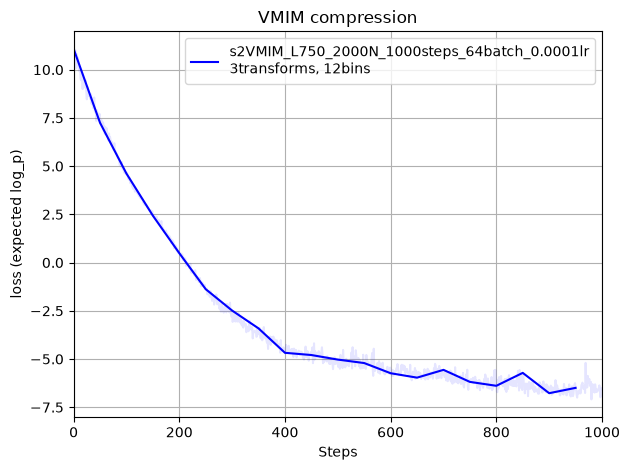

In [46]:
import matplotlib.pyplot as plt

# Training loss time series
fig, ax = plt.subplots()
c = 'blue'
l = f's2VMIM_L750_2000N_{STEPS}steps_{BATCH_SIZE}batch_{LEARNING_RATE}lr' + f'\n{n_transforms}transforms, {n_bins}bins'
# for r,l,c in zip(results_files,labels,colours):
#     with open("compressed_data/"+r, 'rb') as f:
        # load = pickle.load(f)
        # train_lossses = load["train_losses"]
        # test_losses = load["test_losses"]
        # test_steps = load["test_steps"]
ax.plot(range(STEPS), train_losses, color=c, alpha=0.1)
ax.plot(test_steps, test_losses, label=l, color=c)
ax.set_xlim(0,STEPS)
plt.grid()
plt.legend()
plt.xlabel("Steps")
plt.ylabel("loss (expected log_p)")
plt.title(f"VMIM compression")
plt.tight_layout()
plt.savefig(f"examples/plots/{l}.pdf")
plt.show()


Compressed data shape (1984, 5) 
Ground truth shape (1984, 5)


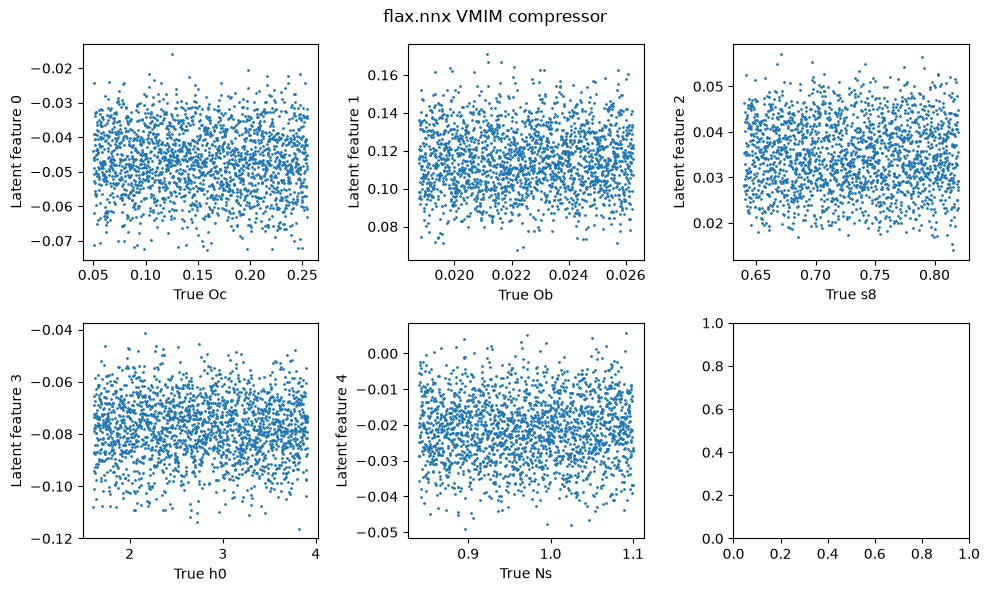

In [47]:
directory="/projects/u6pf/brianycc/spherical_maps/5_tomo_bins_flm_750_batch_1_mwss/"

gt = ground_truth = []
cd = compressed_data = []

dataset = SphericalMapDataset(
    # directory="/projects/u6pf/brianycc/spherical_maps/map_compression_samples_5_tomo_bins_flm_1500_batch_1/", 
    directory = directory, 
    n_maps = 2000, 
    param_filename = "params.npy"
    )
eval_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=4)
for x_batch, p_batch in eval_loader:
    cd.append(S2_VMIM.encode(jnp.asarray(x_batch)))
    gt.append(jnp.asarray(p_batch))
cd = np.concatenate([np.array(d) for d in cd])
gt = np.concatenate([np.array(t) for t in gt])
print("Compressed data shape", cd.shape, "\nGround truth shape", gt.shape)

params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = gt.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cd[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'Latent feature {i}')

plt.suptitle("flax.nnx VMIM compressor")
plt.tight_layout()
# plt.savefig(f"plots/nnx_VMIM_scatter_{STEPS}_steps.pdf")
plt.show()